In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from glob import glob

In [ ]:
experiment_path = (
    "/Users/clairenastaskin/Downloads/06a04de1-eecd-7ddb-8000-043c48409bc9/"
)

# Extract fUSI data and t_r
fusi_path = os.path.join(experiment_path, "pwd.nii")
fusi_data = nib.load(fusi_path)
fusi_data = fusi_data.get_fdata()



# Extract time_stamps
task_path = glob(os.path.join(experiment_path, '*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

logs_path = os.path.join(experiment_path, "logs.parquet")
logs = pd.read_parquet(logs_path)

frame_times_ns = logs["time_ns"].to_numpy()
frame_times_ns = frame_times_ns - frame_times_ns[0]  # Normalize to start at 0
frame_times = frame_times_ns / 1e9  # Convert nanoseconds to seconds

t_r = np.diff(frame_times).mean()
print(f"Estimated t_r: {t_r:.3f} seconds")

Estimated t_r: 2.000 seconds


In [13]:
coords = (86, 20, 80) # Coordinate of the pixel of interest (with high z-score for example from freeview) from the non-realigned data 
radius = 2
timecourse = np.mean(fusi_data[coords[0]-radius:coords[0]+radius,coords[1]-radius:coords[1]+radius,coords[2]-radius:coords[2]+radius,:],axis=(0,1,2))
np.save(
    os.path.join(experiment_path, f"time_course_coord_{coords[0]}-{coords[1]}-{coords[2]}_radius{radius}.npy"),
    timecourse
)
print(timecourse)

[21336.88311027 22081.51964242 22224.61550163 21826.44282403
 21073.73109215 21538.03406617 21722.85312807 21592.00960775
 21193.80208178 21448.83731613 21094.35156756 21474.10460844
 21584.31875142 20669.0077353  22374.22515331 21206.98978931
 19733.95130615 22071.41685918 22254.74728201 22568.91985807
 21341.90570892 22330.26483346 22194.09699283 24265.16801144
 25673.97302328 96743.04697675 24488.99033569 23192.83402079
 24171.23424692 21243.23160012 22703.19042343 23598.95326404
 23017.36260589 24588.47815689 20848.99573184 23121.27220059
 22179.10885554 21504.97229238 22333.52466223 21811.65132681
 21880.32003567 22476.77196349 22920.468042   21212.23793049
 22092.78136653 22213.81396913 21642.13359655 22366.23483713
 22557.51832955 22068.27249951 23283.53617525 21771.50414725
 23110.94780712 21836.43368632 22071.50644243 23871.81808499
 23077.00569308 23304.33320776 21675.84311373 25366.55046063
 23490.87497857 23806.32396673 22193.88548218 22002.4350829
 21795.971172   22247.256

In [14]:
def boxcar_smooth(data, window_size):
    if window_size > 0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(
                data[:, :, :, start_index:end_index], axis=3
            )
    else:
        smoothed_data = data
    return smoothed_data


# Apply temporal smoothing with boxcar window
window_size = 3  # Number of time points to use for smoothing
timecourse = boxcar_smooth(timecourse[np.newaxis, np.newaxis, np.newaxis, :], window_size)[0,0,0,:]

In [15]:
# Detrend signal
from nilearn.signal import clean
# Reshape timecourse to 2D (nilearn expects shape: [n_timepoints, n_features])
timecourse_2d = timecourse[:, np.newaxis]  # Shape: (237, 1)
detrended_timecourse = clean(
    timecourse_2d,
    confounds=None,
    detrend=None,
    standardize=None,       
    low_pass=None,
    high_pass=0.01,
    t_r=t_r,
    ensure_finite=True,      # avoids NaN propagation
)
# Flatten back to 1D if needed
detrended_timecourse = detrended_timecourse.flatten()

In [16]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": frame_times,
        "power_doppler_value": detrended_timecourse,
    }
)

In [17]:
task_list_type = task_events.trial_type.unique()
print(task_list_type)


['words']


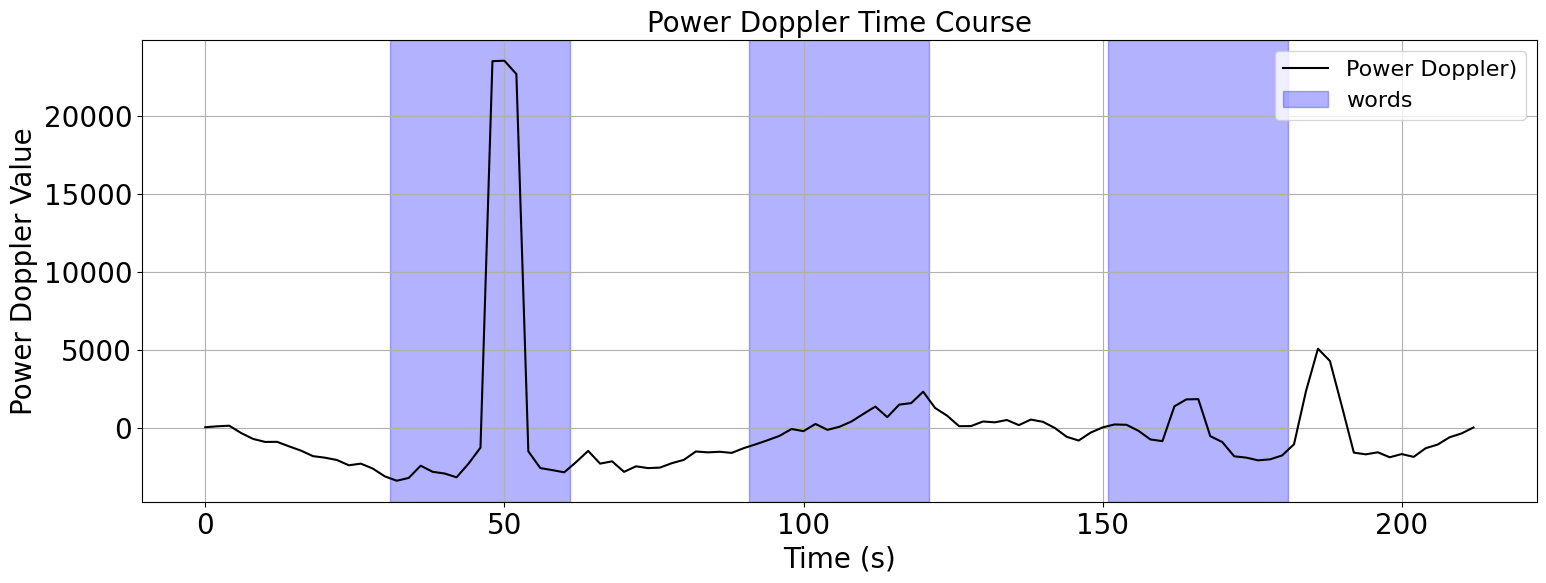

In [18]:
# Smooth the Power Doppler signal using a boxcar of width 2
reaction_time = 0

signal = power_doppler_time_course.power_doppler_value; 

plt.figure(figsize=(18, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    signal,
    color="black",
    label=f"Power Doppler)"
)

task_colors = ['blue','purple', 'gray',  'lightgreen', 'red', 'orange', 'yellow', 'pink']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_events[task_events["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_events[task_events["trial_type"] == task]["onset"],
            task_events[task_events["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    # No need to .values for pandas Series, just use .to_numpy() or direct array ops
    durations = task_events[task_events["trial_type"] == task]["duration"].to_numpy()
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += durations.repeat(1)
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"] + reaction_time
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"] + reaction_time
    # Use .iloc for pandas Series, not numpy arrays
    for i, (start, stop) in enumerate(zip(start_times, stop_times)):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if i == 0 else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.ylim(-9000, 9000)
# plt.xlim(500,1000)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()


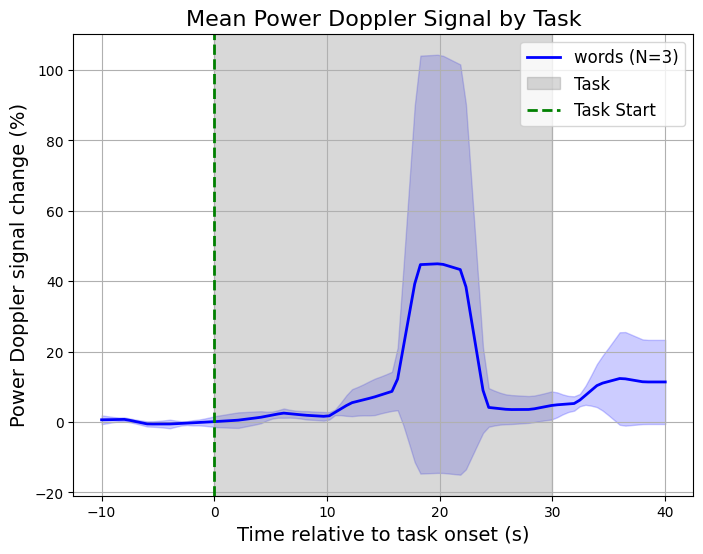

In [19]:

# Time window around events (in seconds)
window_before = 10
window_after = 10

# Use the raw (non-detrended) timecourse for % signal change,
# since the detrended signal has its DC component removed.
raw_time_course = pd.DataFrame(
    {
        "timestamp": frame_times + 1,
        "power_doppler_value": timecourse,
    }
)

plt.figure(figsize=(8, 6))

task_colors = ['blue', 'purple', 'gray', 'lightgreen', 'red', 'orange', 'yellow', 'pink']

for task_index, task in enumerate(task_list_type):
    task_events_filtered = task_events[task_events["trial_type"] == task]

    aligned_signals = []
    aligned_times = []

    for idx, (onset, duration) in enumerate(zip(task_events_filtered["onset"], task_events_filtered["duration"])):
        time_start = onset - window_before
        time_end = onset + duration + window_after

        mask = (raw_time_course["timestamp"] >= time_start) & (raw_time_course["timestamp"] <= time_end)
        subset = raw_time_course[mask].copy()

        if len(subset) < 2:
            continue

        subset["relative_time"] = subset["timestamp"] - onset

        # Convert to % signal change relative to mean baseline (pre-onset)
        baseline_mask = subset["relative_time"] < 0
        if baseline_mask.sum() == 0:
            continue
        baseline_mean = subset.loc[baseline_mask, "power_doppler_value"].mean()
        if baseline_mean == 0 or np.isnan(baseline_mean):
            continue
        pct_change = (subset["power_doppler_value"].values - baseline_mean) / np.abs(baseline_mean) * 100

        aligned_signals.append(pct_change)
        aligned_times.append(subset["relative_time"].values)

    if len(aligned_signals) == 0:
        continue

    # Interpolate onto a common time grid
    common_time = np.linspace(-window_before, task_events_filtered.iloc[0]["duration"] + window_after, 100)
    interpolated = []
    for t, s in zip(aligned_times, aligned_signals):
        interpolated.append(np.interp(common_time, t, s))
    interpolated = np.stack(interpolated)

    mean_signal = interpolated.mean(axis=0)
    std_signal = interpolated.std(axis=0)

    color = task_colors[task_index % len(task_colors)]

    plt.plot(common_time, mean_signal, color=color, linewidth=2,
             label=f'{task} (N={len(aligned_signals)})')
    plt.fill_between(common_time, mean_signal - std_signal, mean_signal + std_signal,
                     color=color, alpha=0.2)

# Shade the task duration in grey
task_duration = task_events_filtered.iloc[0]["duration"]
plt.axvspan(0, task_duration, color='grey', alpha=0.3, label='Task')

# Add vertical line to mark task start
plt.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Task Start')
# plt.ylim(-12, 35)
plt.xlabel("Time relative to task onset (s)", fontsize=14)
plt.ylabel("Power Doppler signal change (%)", fontsize=14)
plt.title("Mean Power Doppler Signal by Task", fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()
